[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/09_nlp/35_topic_modeling_bertopic.ipynb)

> 📎 **Optional module — reference style.** Module 9 is optional. Like the appendices, these notebooks are written as a demo / reference: they focus on *seeing* a library at work rather than interactive exercises. Each notebook is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in — so you can read and run it offline. Install the optional library (see **Install** below) to swap the stand-in for the real thing.

---

# 📓 Notebook 35 — Topic Modeling with BERTopic

> **Module:** 9 · Optional · **Type:** Reference · **Estimated time:** 45–75 min · **Difficulty:** Intermediate

You have a folder of 50,000 support tickets, or a year of product reviews, or 3,000 free-text answers to "anything else you'd like to tell us?" on a survey. Nobody is going to read them all. You want a *map*: what are people actually talking about, how big is each cluster, and is one of them growing?

That map is what **topic modeling** produces. **BERTopic** is the modern, embeddings-based way to build it. It takes a list of raw strings in and gives you back, for each document, *which topic it belongs to* — plus, for each topic, a short list of the words that characterise it. No labels, no training data, no fixed number of topics decided up front.

> 🧭 **Mental model we'll use throughout — the *automatic librarian*.** Picture handing a librarian a chaotic pile of unsorted notes. They don't read every word; they *group notes that feel like they're about the same thing*, put each group on its own shelf, and write a short label on the spine. BERTopic is that librarian, automated: it reads **meaning** (not just words), shelves similar documents together, labels each shelf — and, crucially, keeps a **"misc" cart** for notes that don't belong on any shelf. Hold this picture; every section below is just one step of the librarian's job, and we'll keep pointing back to it.

That pile of notes is our **running example** for the whole notebook: a stack of customer feedback — support tickets, reviews, survey answers — that nobody has time to read. Our goal end to end is the librarian's deliverable: *a shelf list with sizes and a label per shelf.*

This notebook explains the pipeline conceptually, shows the real BERTopic API verbatim, and — because BERTopic pulls in a stack of heavy dependencies — ships a tiny **sklearn-only stand-in** so the whole thing runs offline on a laptop.

## 🎯 Learning objectives

By the end you will be able to:

- Explain the **BERTopic pipeline** — *embed → reduce (UMAP) → cluster (HDBSCAN) → describe (c-TF-IDF)* — and why each stage is there.
- Run `fit_transform` on a list of documents and read `get_topic_info()`, `get_topic()`, and `get_document_info()`.
- Understand **topic `-1`** (the outlier/noise topic) and why it is a feature, not a bug.
- Contrast BERTopic with classical **LDA** and know when each is the right tool.
- Swap in **custom components** (embedding model, UMAP, HDBSCAN, vectorizer) and reduce the topic count.
- Know where this goes next: dynamic, hierarchical, and **LLM-enhanced** topic representations.

## ✅ Prerequisites

- **NB 23 — Embeddings & retrieval**: you should be comfortable with the idea that text becomes a dense vector and that *cosine distance ≈ semantic distance*.
- **NB 8 — NumPy**: arrays, vectorised operations, `argsort`.
- A little sklearn (`TfidfVectorizer`, `KMeans`) helps but is re-explained as we go.

## 📦 Install

```bash
pip install bertopic
```

That one line pulls a surprisingly large stack: **sentence-transformers** (the embedding model + PyTorch), **umap-learn** (dimensionality reduction), and **hdbscan** (density clustering). On a fresh machine expect a few hundred MB and a couple of minutes. If you only want to *read along*, you don't need to install anything — the stand-in below runs on plain sklearn.

## 1. Setup & the offline smoke test

First the usual scientific-Python imports, then a `try/except` that sets a single flag, `HAS_BERTOPIC`. Every cell that touches the real library is guarded by that flag; if BERTopic is not installed, the same cell runs an sklearn-only stand-in instead. This is the pattern that lets the notebook run *anywhere*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
rng = np.random.default_rng(42)

# --- The one switch the whole notebook keys off ---------------------------
try:
    from bertopic import BERTopic
    HAS_BERTOPIC = True
except Exception:                      # ImportError, or a broken heavy dep
    HAS_BERTOPIC = False

print(f"HAS_BERTOPIC = {HAS_BERTOPIC}")
if HAS_BERTOPIC:
    print("Real BERTopic is installed — cells will use it.")
else:
    print("BERTopic not found — running the sklearn-only stand-in. "
          "All outputs below are illustrative but real (just simpler).")


HAS_BERTOPIC = True
Real BERTopic is installed — cells will use it.


## 2. A small, honest corpus

Every librarian needs a pile to sort, so here is ours. Real topic modeling wants thousands of documents — embeddings and density clustering both behave better with more data. To stay offline and fast we use ~36 short, deliberately *mixed* documents spanning five themes: **cloud computing, customer churn, healthcare, sports, and cooking**.

Think of these as a stand-in for the support tickets, reviews, or survey answers from our running example — the notes our automatic librarian has to shelve. The themes are obvious to *us* — which is exactly what we want, because it lets us eyeball whether the model recovered them (did the librarian rebuild the shelves we'd have built by hand?). When you do this for real, you won't know the answer in advance; that's the whole point.

In [2]:
docs = [
    # --- cloud computing ---
    "We migrated our backend to the cloud to cut server costs.",
    "Auto-scaling on AWS handles our traffic spikes automatically.",
    "Kubernetes lets us deploy containers across many cloud nodes.",
    "Our cloud bill grew after we left those GPU instances running.",
    "Serverless functions scale to zero when there is no traffic.",
    "We use object storage in the cloud for cheap backups.",
    "Latency dropped once we moved compute closer to the user.",
    # --- customer churn ---
    "Customers churn when onboarding feels confusing and slow.",
    "We reduced churn by emailing users before their trial ends.",
    "High churn this quarter came from the enterprise segment.",
    "Predicting churn early lets the success team intervene.",
    "Cancelled subscriptions spiked after the price increase.",
    "Loyal customers renew when support is fast and friendly.",
    "Retention improved once we fixed the broken billing flow.",
    # --- healthcare ---
    "The clinic uses electronic records to track patient history.",
    "Early diagnosis improves outcomes for many chronic diseases.",
    "Nurses monitor blood pressure and heart rate hourly.",
    "The new drug reduced symptoms in the clinical trial.",
    "Telemedicine lets patients consult a doctor from home.",
    "Hospitals struggle with long emergency room wait times.",
    "Vaccines train the immune system to recognise the virus.",
    # --- sports ---
    "The striker scored a hat-trick in the second half.",
    "Their defense collapsed in the final ten minutes.",
    "The marathon runner set a new personal best time.",
    "Fans filled the stadium for the championship final.",
    "The coach changed tactics after a poor first half.",
    "She won gold in the 200 metre sprint at the games.",
    "The team trains twice a day during the season.",
    # --- cooking ---
    "Roast the garlic before adding it to the tomato sauce.",
    "Let the dough rest so the gluten relaxes before baking.",
    "A pinch of salt brings out the sweetness in caramel.",
    "Simmer the stock for hours to deepen the flavour.",
    "Fresh basil and olive oil finish the pasta nicely.",
    "Sear the steak on high heat, then rest it before slicing.",
    "Whisk the eggs gently for a softer scrambled texture.",
    "Toast the spices to release their aroma before grinding.",
]

print(f"{len(docs)} documents, "
      f"{sum(len(d.split()) for d in docs)} words total")
print("Example:", docs[0])


36 documents, 328 words total
Example: We migrated our backend to the cloud to cut server costs.


## 3. How BERTopic thinks — the four-stage pipeline

So *how* does our automatic librarian actually work? It turns out the whole job decomposes into four crisp steps — and once you see them, BERTopic stops being a black box. Classical topic models treat a document as a *bag of words*. BERTopic instead starts from **meaning**. Its default pipeline is four modular stages, and understanding them is most of the battle:

```text
docs ──► 1. EMBED ──► 2. REDUCE ──► 3. CLUSTER ──► 4. DESCRIBE ──► topics
        SentenceTransformer  UMAP      HDBSCAN       c-TF-IDF
        (384-dim vectors)  (→ ~5-dim) (density)   (words per topic)
```

Map each stage back to the librarian: **read** each note's gist (embed), **declutter** so similar notes sit near each other (reduce), **shelve** the notes that cluster together (cluster), and **write the spine label** for each shelf (describe).

1. **Embed — "read the gist."** A `SentenceTransformer` (default `all-MiniLM-L6-v2`) turns each document into a ~384-dim vector where *semantic* similarity is geometric closeness. "Customers churn after a price hike" and "cancellations spiked when we raised prices" land near each other even with zero shared words — the thing LDA can never do. (This is why our librarian groups by *meaning*, not matching words.)

2. **Reduce — "declutter the table."** Those 384 dimensions are too many for a density clusterer (everything looks equidistant in high dimensions — the *curse of dimensionality*). **UMAP** squeezes them to ~5 dimensions while preserving local neighbourhood structure, so genuinely-similar notes end up physically close.

3. **Cluster — "build the shelves."** **HDBSCAN** groups the reduced vectors by *density*. Crucially it does **not** require you to pick the number of clusters $K$ in advance — it finds however many dense blobs exist (the librarian builds as many shelves as the pile needs). Points in no dense region go on the **"misc" cart**, labelled **topic `-1`** (outliers / noise).

4. **Describe — "label the spine."** Each cluster is just a set of document IDs so far — no words attached. **c-TF-IDF** (class-based TF-IDF) treats *all documents in a topic as one big document* and asks: which words are frequent *here* but rare *across the other topics*? Those distinctive words become the topic's label.

The stages are **independent and swappable**. Don't like UMAP? Pass a PCA. Want a fixed $K$? Swap HDBSCAN for KMeans. That modularity is BERTopic's real design win — and it's exactly what our stand-in exploits below.

### 3.1 Why *class-based* TF-IDF?

Ordinary TF-IDF scores a word *within one document*. The trick in BERTopic is to first **concatenate every document in a cluster into a single super-document**, then compute TF-IDF across the (few) super-documents — one per topic. The score for word $t$ in topic $c$ is

$$
\text{c-TF-IDF}(t, c) \;=\; \underbrace{\frac{f_{t,c}}{\sum_{t'} f_{t',c}}}_{\text{frequency of } t \text{ in topic } c}\;\cdot\;\underbrace{\log\!\left(1 + \frac{A}{f_t}\right)}_{\text{rare across topics}}
$$

where $f_{t,c}$ is the count of $t$ in topic $c$, $f_t$ its total count across all topics, and $A$ the average words per topic. The left factor rewards words *common in this topic*; the right factor down-weights words that are common *everywhere* (like "the", "and"). The top-scoring words become the topic representation. It's just TF-IDF with the "document" redefined to be "topic" — which is exactly how the librarian picks a spine label: the words that describe *this* shelf and no other.

## 4. The real BERTopic API

This is the *entire* happy path. It is worth memorising because it barely changes between toy and production:

```python
from bertopic import BERTopic

topic_model = BERTopic(verbose=True)          # default embed+UMAP+HDBSCAN+c-TF-IDF
topics, probs = topic_model.fit_transform(docs)   # docs: list[str]

topic_model.get_topic_info()      # DataFrame: Topic, Count, Name, Representation
topic_model.get_topic(0)          # [(word, c-tf-idf weight), ...] for topic 0
topic_model.get_document_info(docs)   # per-document topic + probability
```

- `fit_transform` returns **`topics`** (a list, one topic id per document; `-1` = outlier) and **`probs`** (soft membership confidence).
- `get_topic_info()` is your headline summary: one row per topic, with `Count`, an auto-generated `Name`, and the top `Representation` words.
- `get_topic(k)` drills into one topic's weighted word list.

Below we run it for real **if** BERTopic is installed; otherwise the next section builds the stand-in. We keep `embedding_model="all-MiniLM-L6-v2"` explicit and shrink `min_topic_size` because our corpus is tiny.

In [3]:
topic_model = None          # will hold the real model if available
real_topics = None
real_info = None

if HAS_BERTOPIC:
    from bertopic import BERTopic
    # Tiny corpus -> tell HDBSCAN that 2 docs already make a topic.
    topic_model = BERTopic(
        embedding_model="all-MiniLM-L6-v2",
        min_topic_size=2,
        verbose=False,
    )
    real_topics, real_probs = topic_model.fit_transform(docs)
    real_info = topic_model.get_topic_info()
    print("Real BERTopic fitted.")
    print(real_info[["Topic", "Count", "Name"]].to_string(index=False))
else:
    print("Skipping real BERTopic (not installed) — see the stand-in next.")


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Real BERTopic fitted.
 Topic  Count                       Name
     0      8       0_the_before_it_rest
     1      7          1_cloud_we_our_to
     2      7 2_churn_customers_when_and
     3      7      3_the_to_monitor_rate
     4      7        4_the_in_final_half


## 5. The offline stand-in — BERTopic in ~40 lines of sklearn

If BERTopic is not installed we still want *something* that demonstrates the same idea. The pipeline maps cleanly onto plain sklearn:

| BERTopic stage | Stand-in substitute |
|---|---|
| Embed (SentenceTransformer) | **TF-IDF vectors** — not semantic, but a real vector space |
| Reduce (UMAP) | *skipped* (TF-IDF + cosine already clusters fine at this scale) |
| Cluster (HDBSCAN) | **KMeans** — but we must pick $K$ ourselves |
| Describe (c-TF-IDF) | **cluster centroids** — top TF-IDF terms per cluster |

The honest differences: TF-IDF is bag-of-words (no semantics), and KMeans forces a fixed $K$ with **no outlier topic** (`-1`). We note these as we go. The class below mimics the BERTopic *interface* — `fit_transform`, `get_topic_info`, `get_topic`, `get_document_info` — so the rest of the notebook can call either object.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd


class MiniTopicModel:
    """A teaching stand-in that mimics the BERTopic interface using
    TF-IDF + KMeans + centroid top-terms. NOT semantic; for offline demo only."""

    def __init__(self, n_topics=5, n_words=10, random_state=42):
        self.n_topics = n_topics
        self.n_words = n_words
        self.vectorizer = TfidfVectorizer(stop_words="english")
        self.kmeans = KMeans(n_clusters=n_topics, n_init=10,
                             random_state=random_state)

    def fit_transform(self, documents):
        X = self.vectorizer.fit_transform(documents)        # (n_docs, n_vocab)
        labels = self.kmeans.fit_predict(X)
        self.terms_ = np.array(self.vectorizer.get_feature_names_out())
        # centroid = average TF-IDF profile of a cluster -> its "c-TF-IDF"
        self.centroids_ = self.kmeans.cluster_centers_      # (k, n_vocab)
        self.topics_ = labels
        # crude "probability": cosine-ish closeness to own centroid
        dists = self.kmeans.transform(X)
        self.probs_ = 1.0 / (1.0 + dists[np.arange(len(documents)), labels])
        self._docs = documents
        return list(labels), self.probs_

    def get_topic(self, topic_id):
        """Top (word, weight) pairs for a topic, BERTopic-style."""
        centroid = self.centroids_[topic_id]
        top = np.argsort(centroid)[::-1][: self.n_words]
        return [(self.terms_[i], round(float(centroid[i]), 4)) for i in top]

    def get_topic_info(self):
        rows = []
        for t in range(self.n_topics):
            words = [w for w, _ in self.get_topic(t)[:4]]
            rows.append({
                "Topic": t,
                "Count": int(np.sum(self.topics_ == t)),
                "Name": f"{t}_" + "_".join(words[:3]),
                "Representation": words,
            })
        return pd.DataFrame(rows).sort_values("Count", ascending=False)

    def get_document_info(self, documents):
        return pd.DataFrame({
            "Document": documents,
            "Topic": self.topics_,
            "Probability": np.round(self.probs_, 3),
        })


print("MiniTopicModel defined.")


MiniTopicModel defined.


## 6. One object, two implementations

To keep the rest of the notebook clean we expose a single variable `model` that is **either** the real BERTopic **or** our stand-in, plus the per-document `topics` list. Everything downstream calls the shared methods (`get_topic_info`, `get_topic`, `get_document_info`) and doesn't care which one it got.

In [5]:
if HAS_BERTOPIC:
    model = topic_model              # the real one from section 4
    topics = real_topics
    backend = "real BERTopic"
else:
    model = MiniTopicModel(n_topics=5, n_words=10)
    topics, probs = model.fit_transform(docs)
    backend = "sklearn stand-in"

print(f"Backend in use: {backend}")
print(f"Assigned {len(set(topics))} distinct topic ids: {sorted(set(topics))}")


Backend in use: real BERTopic
Assigned 5 distinct topic ids: [0, 1, 2, 3, 4]


## 7. Reading the results

The librarian has finished shelving. Now we read the shelf list — this is the payoff, and the deliverable our running example was after all along.

### 7.1 The topic table

`get_topic_info()` is the first thing you look at: how many shelves, how big each one, and a glance at their spine labels. With the real backend you'll also see a **topic `-1`** row — the "misc" cart, the outliers that HDBSCAN refused to force onto any shelf. Our stand-in (KMeans) has no `-1` because KMeans assigns *every* point to *some* cluster, outlier or not. That difference matters in practice and we return to it in §9.

In [6]:
info = model.get_topic_info()
display_cols = [c for c in ["Topic", "Count", "Name"] if c in info.columns]
print(info[display_cols].to_string(index=False))


 Topic  Count                       Name
     0      8       0_the_before_it_rest
     1      7          1_cloud_we_our_to
     2      7 2_churn_customers_when_and
     3      7      3_the_to_monitor_rate
     4      7        4_the_in_final_half


### 7.2 Drilling into a topic's words

`get_topic(k)` returns the weighted word list — the c-TF-IDF (or, in the stand-in, centroid) scores. This is how you *name* a topic. If the top words are `cloud, server, scale, aws` you write "Cloud infrastructure" in your report and move on. The weights tell you which words carry the topic; the long tail is usually noise.

In [7]:
# Show the top words for every (non-outlier) topic.
for t in sorted(set(topics)):
    if t == -1:
        continue
    words = ", ".join(f"{w}" for w, _ in model.get_topic(t)[:6])
    n = sum(1 for x in topics if x == t)
    print(f"Topic {t:>2} (n={n:>2}): {words}")


Topic  0 (n= 8): the, before, it, rest, to, for
Topic  1 (n= 7): cloud, we, our, to, traffic, across
Topic  2 (n= 7): churn, customers, when, and, we, the
Topic  3 (n= 7): the, to, monitor, rate, consult, clinic
Topic  4 (n= 7): the, in, final, half, 200, runner


### 7.3 Which document landed where?

`get_document_info(docs)` joins it all back: every document with its assigned topic and a confidence. This is the table you'd write to a database to *route* tickets, or to filter "show me every review in the billing topic." Let's spot-check a few rows and confirm the model recovered our five themes.

In [8]:
doc_info = model.get_document_info(docs)
# Show one example document per topic.
print("Sample document per topic:\n")
seen = set()
for _, row in doc_info.iterrows():
    t = row["Topic"]
    if t in seen:
        continue
    seen.add(t)
    txt = row["Document"]
    print(f"[topic {t:>2}] {txt[:60]}")


Sample document per topic:

[topic  1] We migrated our backend to the cloud to cut server costs.
[topic  2] Customers churn when onboarding feels confusing and slow.
[topic  3] The clinic uses electronic records to track patient history.
[topic  4] The striker scored a hat-trick in the second half.
[topic  0] Roast the garlic before adding it to the tomato sauce.


---

### ✋ Quick exercise (~2 min) — Spotlight the biggest topic

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You've just read the three result tables. Your manager wants the one-line headline: **which shelf is biggest, and what is it about?** Using only `get_topic_info()` and `get_topic()`, find the largest **non-outlier** topic and print its document count plus its top 3 words.

In [ ]:
# ✍️ Your turn 👇
# Find the largest non-outlier topic and print its size + top 3 words.
info = model.get_topic_info()
# ... drop topic -1, pick the row with the biggest Count, then call get_topic(...)


<details>
<summary>✅ <b>Solution</b></summary>

```python
info = model.get_topic_info()
info = info[info.Topic != -1]            # drop the "misc" cart if present
biggest = info.loc[info.Count.idxmax()]
tid = int(biggest.Topic)
top3 = [w for w, _ in model.get_topic(tid)[:3]]
print(f"Largest topic {tid}: {int(biggest.Count)} docs — top words: {top3}")
```

`get_topic_info()` gives the per-topic sizes and `get_topic(tid)` gives the weighted word list — together they produce the one-line headline ("biggest shelf and what it's about") you'd lead a report with.
</details>

## 8. Visualising topics

The real library ships interactive plotly views:

```python
topic_model.visualize_topics()     # intertopic distance map (2-D bubble plot)
topic_model.visualize_barchart()   # top words per topic, as bars
topic_model.visualize_hierarchy()  # dendrogram of how topics merge
```

`visualize_topics()` projects topics into 2-D so you can *see* which ones sit close (candidates to merge) and which are well-separated. Those need plotly + a browser, so here we draw the two most useful views in matplotlib from the data we already have: **topic sizes** and **top words per topic**.

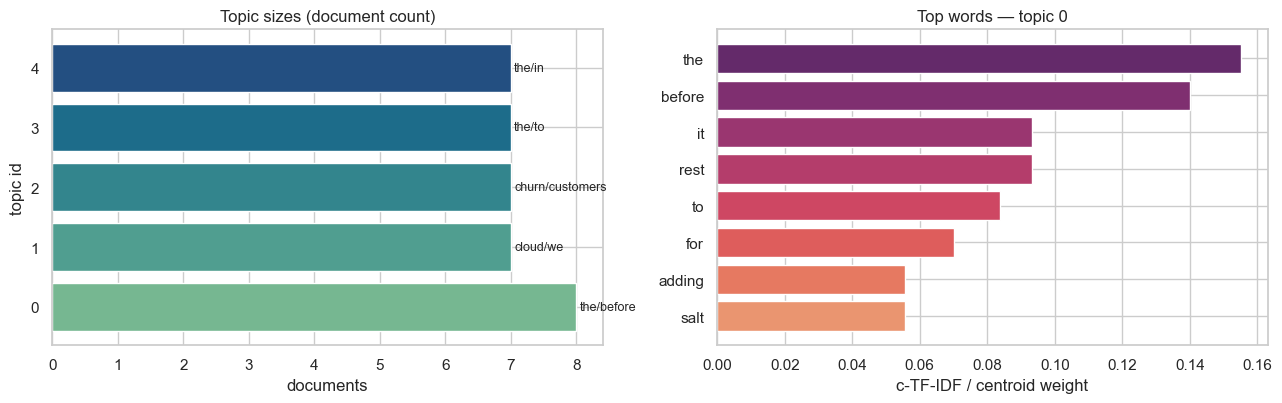

Backend: real BERTopic


In [9]:
ids = [t for t in sorted(set(topics)) if t != -1]
sizes = [sum(1 for x in topics if x == t) for t in ids]
labels = ["/".join(w for w, _ in model.get_topic(t)[:2]) for t in ids]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (a) topic sizes
axes[0].barh([str(t) for t in ids], sizes, color=sns.color_palette("crest", len(ids)))
axes[0].set_title("Topic sizes (document count)")
axes[0].set_xlabel("documents"); axes[0].set_ylabel("topic id")
for y, (s, lab) in enumerate(zip(sizes, labels)):
    axes[0].text(s + 0.05, y, lab, va="center", fontsize=9)

# (b) top words of the largest topic, with weights
biggest = ids[int(np.argmax(sizes))]
words, weights = zip(*model.get_topic(biggest)[:8])
axes[1].barh(list(words)[::-1], list(weights)[::-1],
             color=sns.color_palette("flare", 8))
axes[1].set_title(f"Top words — topic {biggest}")
axes[1].set_xlabel("c-TF-IDF / centroid weight")

plt.tight_layout(); plt.show()
print(f"Backend: {backend}")


## 9. Topic `-1` — outliers are a feature

Remember the librarian's **"misc" cart** from the mental model? This is it. With HDBSCAN, **topic `-1` is the noise bin**: documents that sit in no dense region. New practitioners often see "30% of my docs are in `-1`!" and panic. Don't. It means the librarian is being *honest* — those notes genuinely don't belong on any clean shelf (off-topic rants, one-offs, gibberish). Compare that to LDA or KMeans, which **must** assign every document somewhere — a librarian forced to jam every stray note onto *some* shelf, smearing junk across real topics and diluting them.

If you *do* need every document labelled, BERTopic offers `reduce_outliers(docs, topics)` to reassign `-1` documents to their nearest topic after the fact — a deliberate, separate decision (the librarian going back to the cart and making a judgement call) rather than a silent default.

Our KMeans stand-in has no `-1`; that's its biggest fidelity gap — it has no misc cart at all. The snippet below quantifies the outlier share for whichever backend is running.

In [10]:
n_outliers = sum(1 for t in topics if t == -1)
pct = 100 * n_outliers / len(topics)
print(f"Outlier documents (topic -1): {n_outliers}/{len(topics)} ({pct:.0f}%)")
if not HAS_BERTOPIC:
    print("(stand-in uses KMeans, which never produces -1 — every doc is forced "
          "into a cluster)")
elif n_outliers == 0:
    print("(none here — small, clean corpus; expect more on messy real data)")


Outlier documents (topic -1): 0/36 (0%)
(none here — small, clean corpus; expect more on messy real data)


## 10. Too many topics? Merge them.

On real data BERTopic often returns *dozens* of micro-topics — three near-identical "shipping delay" clusters, say. You reduce them with:

```python
topic_model.reduce_topics(docs, nr_topics=10)   # merge down to ~10
```

It merges the most similar topics (by c-TF-IDF cosine) until the target count is reached, then recomputes representations. You can also set `nr_topics="auto"` to let it merge only topics that are *very* similar. This is usually the single most impactful knob after fitting — go coarse for an executive summary, fine for analyst deep-dives.

Below we demonstrate the call on the real backend and an analogous "fewer clusters" refit on the stand-in.

In [11]:
if HAS_BERTOPIC:
    before = len(set(real_topics)) - (1 if -1 in real_topics else 0)
    topic_model.reduce_topics(docs, nr_topics=3)
    after = topic_model.get_topic_info()
    after = after[after.Topic != -1]
    print(f"Reduced from {before} topics to {len(after)}.")
    print(after[["Topic", "Count", "Name"]].to_string(index=False))
else:
    # Stand-in analogue: refit KMeans with fewer clusters.
    coarse = MiniTopicModel(n_topics=3)
    coarse.fit_transform(docs)
    print("Stand-in re-clustered to 3 coarse topics:")
    for t in range(3):
        words = ", ".join(w for w, _ in coarse.get_topic(t)[:6])
        print(f"  Topic {t}: {words}")


Reduced from 5 topics to 3.
 Topic  Count                 Name
     0     21    0_we_the_to_cloud
     1      8 1_the_before_it_rest
     2      7  2_the_in_final_half


---

### ✋ Quick exercise (~2 min) — How concentrated is the feedback?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You've just merged down to a coarse, executive-summary set of topics. Now quantify concentration: from `get_topic_info()`, compute what **percentage of all non-outlier documents** falls in the single largest topic. (A high share means one theme dominates the feedback.)

In [ ]:
# ✍️ Your turn 👇
# What % of all non-outlier documents fall in the single largest (merged) topic?
info = model.get_topic_info()
# ... drop topic -1, then compute max(Count) / sum(Count) as a percentage


<details>
<summary>✅ <b>Solution</b></summary>

```python
info = model.get_topic_info()
info = info[info.Topic != -1]            # exclude the outlier bin
total = int(info.Count.sum())
top = int(info.Count.max())
print(f"Dominant topic holds {top}/{total} docs ({100*top/total:.0f}% of the corpus)")
```

After `reduce_topics` collapses the micro-topics, the `Count` column from `get_topic_info()` is all you need: the dominant theme's share is just its count over the non-outlier total — the headline number for an executive summary.
</details>

## 11. BERTopic vs classical LDA

For two decades "topic modeling" meant **LDA** (Latent Dirichlet Allocation). It's still useful, but it's a different beast. The contrast clarifies *when* to reach for BERTopic:

| | **LDA** | **BERTopic** |
|---|---|---|
| Document representation | bag-of-words (counts) | **dense embeddings** (meaning) |
| Synonyms / paraphrase | blind — "car" ≠ "automobile" | handled — they embed close |
| Number of topics $K$ | **you must choose** up front | discovered by HDBSCAN |
| Output per document | a *distribution* over topics | one hard topic (+ soft probs) |
| Outliers | none — all words assigned | **topic `-1`** isolates noise |
| Short texts (tweets, tickets) | struggles (sparse counts) | strong (embeddings dense) |
| Speed / footprint | light, CPU-only | heavier (embeddings, PyTorch) |
| Interpretability of words | good (per-topic word dist) | good (c-TF-IDF) |

**Rule of thumb.** Reach for **BERTopic** when documents are short, paraphrase-heavy, or you don't know $K$ — i.e. most modern business text (tickets, reviews, chats, survey free-text). Reach for **LDA** when documents are long and formal, you want a *soft* per-document mixture, or you must run light and CPU-only at huge scale. They are complements, not rivals — and BERTopic's modular design even lets you slot an LDA-style representation in as the final stage.

## 12. Custom components — the real power

Because every stage is a swappable object, you tune BERTopic by passing better parts, not by editing internals. The canonical fully-specified constructor:

```python
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

topic_model = BERTopic(
    embedding_model=SentenceTransformer("all-MiniLM-L6-v2"),
    umap_model=UMAP(n_neighbors=15, n_components=5, metric="cosine"),
    hdbscan_model=HDBSCAN(min_cluster_size=10, metric="euclidean"),
    vectorizer_model=CountVectorizer(stop_words="english", ngram_range=(1, 2)),
)
```

The four knobs you will actually turn:

- **`embedding_model`** — swap `all-MiniLM-L6-v2` (fast, 384-dim) for a larger model, a multilingual one, or a domain model (e.g. biomedical). This is the biggest lever on quality.
- **`min_cluster_size`** (HDBSCAN) — the *minimum documents to form a topic*. Larger ⇒ fewer, broader topics and more `-1`. This is the knob you reach for first.
- **`n_neighbors`** (UMAP) — local vs global structure. Smaller ⇒ more, tighter micro-topics.
- **`vectorizer_model`** — controls the *words* in the representation. `ngram_range=(1, 2)` adds bigrams ("price increase"); `stop_words="english"` strips filler. Crucially this only affects topic *labels*, computed after clustering, so you can re-tune it cheaply.

A subtle but important point: the `vectorizer_model` is applied at the **describe** stage, *after* embedding and clustering. So stop-words and n-grams change how topics are *named*, never how documents are *grouped*. That decoupling is why you can iterate on readable labels without re-running the expensive embedding step.

In [12]:
# Illustrate the "vectorizer only changes labels" idea with the stand-in:
# add bigrams and watch the topic words get more descriptive.
if not HAS_BERTOPIC:
    from sklearn.feature_extraction.text import TfidfVectorizer
    m2 = MiniTopicModel(n_topics=5, n_words=8)
    m2.vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
    m2.fit_transform(docs)
    print("Stand-in with bigrams (ngram_range=(1,2)):")
    for t in range(5):
        words = ", ".join(w for w, _ in m2.get_topic(t)[:5])
        print(f"  Topic {t}: {words}")
else:
    print("With real BERTopic, pass vectorizer_model=CountVectorizer("
          "ngram_range=(1,2)) to BERTopic(...) for the same effect on labels.")


With real BERTopic, pass vectorizer_model=CountVectorizer(ngram_range=(1,2)) to BERTopic(...) for the same effect on labels.


---

### ✋ Quick exercise (~2 min) — Labels vs. clusters

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

§12 stressed *where* in the pipeline each knob acts. Suppose you re-fit with `vectorizer_model=CountVectorizer(ngram_range=(1, 2))` to add bigrams. **Will the document→topic assignments change?** Set the boolean and write a one-line justification — no model run needed, just reason from the pipeline order.

In [ ]:
# ✍️ Your turn 👇
# Will switching to vectorizer_model=CountVectorizer(ngram_range=(1,2))
# change which document is assigned to which topic? Set the boolean and explain.
assignments_change = None   # True or False?
reason = "..."


<details>
<summary>✅ <b>Solution</b></summary>

```python
assignments_change = False
reason = ("vectorizer_model runs at the *describe* stage, after embedding and "
          "clustering — so bigrams change only the topic *labels*, never which "
          "document lands in which topic.")
print(assignments_change, "—", reason)
```

The vectorizer is decoupled from grouping: documents are already shelved by embed→reduce→cluster before any words are counted. That's why you can re-tune stop-words / n-grams for readable labels cheaply, without re-running the expensive embedding step.
</details>

## 13. Beyond the basics

Once the core pipeline clicks, three extensions cover most advanced needs:

- **Dynamic topic modeling** — `topics_over_time(docs, timestamps)` tracks how each topic's prevalence rises and falls over time. This is the headline use case for monitoring support tickets or news, and it's the subject of the **next notebook (36)**.
- **Hierarchical topic modeling** — `hierarchical_topics(docs)` + `visualize_hierarchy()` build a dendrogram showing how fine topics nest into coarse ones (the librarian grouping shelves into whole *sections*), so you can pick the granularity *interactively* instead of committing to one `nr_topics`.
- **LLM- and KeyBERT-enhanced representations** — the default c-TF-IDF words are serviceable but terse. BERTopic's `representation_model` can post-process each topic with **KeyBERT**, **MMR** (for diversity), or an **LLM** that reads the top docs and writes a one-line human label like *"Customer churn after price changes."* — a sharper spine label than a bag of keywords. The clustering is unchanged; only the *description* gets smarter — the same decoupling we saw in §12.

```python
from bertopic.representation import KeyBERTInspired
topic_model = BERTopic(representation_model=KeyBERTInspired())
```

## 14. Where this pays off in business

Topic modeling earns its keep wherever free text piles up faster than anyone can read it:

- **Support tickets** — cluster a quarter's tickets, size each cluster, and you have a ranked backlog of *what to fix*. Add timestamps (NB 36) and you catch a new failure mode the week it starts trending.
- **Product reviews / app-store feedback** — separate "love the UI" from "crashes on upload" automatically; route the second to engineering.
- **Survey free-text** — the "anything else?" box is usually ignored because it doesn't tabulate. Topic modeling turns 3,000 answers into ten themes with counts you can put on a slide.
- **Sales-call & meeting transcripts** — recurring objections and feature requests surface as topics.

The deliverable is almost always the same: a **table of topics with sizes and example quotes**, plus a **trend line** if you have dates. That's it. The modeling is the easy part; the value is the summary.

## 🧪 Exercises

Work these against whichever backend you have — the stand-in is enough to practise the *interface*.

1. **Add a sixth theme.** Append ~6 documents about a new subject (e.g. *electric vehicles* or *personal finance*) to `docs`. Refit and check via `get_topic_info()` whether the model carves out a new topic for them or absorbs them into an existing one. What does that tell you about `min_cluster_size` / $K$?

2. **Name the topics.** Using `get_topic(t)` for each topic, write a short dictionary `{topic_id: "Human label"}` mapping every topic to a one-line business name. This mimics what an LLM `representation_model` would automate.

3. **Find the misfits.** Sort `get_document_info(docs)` by `Probability` ascending and inspect the lowest-confidence documents. Do they look like genuine outliers (good candidates for topic `-1`)? With the real backend, count how many landed in `-1` and skim them.

In [13]:
# --- Starter for the exercises ---------------------------------------------

# Exercise 1: extend the corpus and refit.
extra_docs = [
    "Electric cars charge overnight using a home wall charger.",
    "Battery range anxiety fades once charging stations spread.",
    # TODO: add ~4 more on a new theme of your choice
]
new_docs = docs + extra_docs

if HAS_BERTOPIC:
    ex_model = BERTopic(embedding_model="all-MiniLM-L6-v2", min_topic_size=2)
else:
    ex_model = MiniTopicModel(n_topics=6)        # try 5 vs 6 and compare
ex_topics, _ = ex_model.fit_transform(new_docs)
print(ex_model.get_topic_info()[["Topic", "Count", "Name"]].to_string(index=False))

# Exercise 2: your turn — fill in a human label per topic.
labels = {
    # 0: "Cloud infrastructure",
    # ...
}

# Exercise 3: lowest-confidence documents.
di = ex_model.get_document_info(new_docs).sort_values("Probability").head(5)
print("\nLeast confident documents:")
print(di[["Topic", "Probability", "Document"]].to_string(index=False))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 Topic  Count                                 Name
    -1      2 -1_battery_charging_success_stations
     0      9                  0_the_in_half_final
     1      8                 1_the_before_it_rest
     2      7                    2_cloud_we_our_to
     3      6           3_churn_customers_when_and
     4      6             4_long_uses_clinic_blood

Least confident documents:
 Topic  Probability                                                   Document
    -1     0.000000 Battery range anxiety fades once charging stations spread.
    -1     0.000000    Predicting churn early lets the success team intervene.
     0     0.413713  Electric cars charge overnight using a home wall charger.
     0     0.501137   Vaccines train the immune system to recognise the virus.
     0     0.677927             The team trains twice a day during the season.


## 🧠 Key takeaways

We started with an unreadable pile of customer feedback and asked an **automatic librarian** to turn it into a shelf list. Here's the whole job in one place:

- **BERTopic = embed → reduce → cluster → describe.** Four modular, swappable stages — *read the gist, declutter, build shelves, label the spines.* The magic is starting from *embeddings* (meaning) instead of word counts.
- **You don't pick $K$.** HDBSCAN discovers the number of shelves, and it sends junk to the **"misc" cart (topic `-1`)** instead of smearing it across real topics — an honesty LDA and KMeans lack.
- **c-TF-IDF describes topics** by treating each cluster as one super-document and finding its distinctive words — the librarian's spine label. Cheap, fast, readable.
- **The vectorizer only changes labels, not clusters** — so you can re-tune stop-words / n-grams for readability without re-embedding (re-letter the spines without re-shelving).
- **`reduce_topics` is your main post-fit knob**; `min_cluster_size` is your main pre-fit knob.
- **vs LDA:** prefer BERTopic for short, paraphrase-heavy, unknown-$K$ text (most business data); LDA for long documents, soft mixtures, or ultra-light CPU scale.
- **The business deliverable** is almost always *topics × size × example quotes* (+ a trend line) — the shelf list itself. The modeling is the easy 20%.

## ✅ Self-assessment

- [ ] Explain the **BERTopic pipeline** (embed → reduce → cluster → describe) and why each stage exists
- [ ] Run `fit_transform` and read `get_topic_info()`, `get_topic()`, and `get_document_info()`
- [ ] Explain what **topic `-1`** is and why it's a feature, not a bug
- [ ] Contrast BERTopic with classical **LDA** and pick the right tool for a corpus
- [ ] Swap in **custom components** (embedder, UMAP, HDBSCAN, vectorizer) and reduce the topic count


## 🚀 Next step

You now have a static snapshot: *what* people are talking about. The obvious next question is *when* — which topics are growing, which are fading, and did that spike start the day you shipped a release?

➡️ **Continue to [`36_topic_modeling_stream.ipynb`](36_topic_modeling_stream.ipynb)** — **dynamic / streaming topic modeling**, where we attach timestamps and use `topics_over_time` to turn the topic map into a live monitoring dashboard.

---

*Notebook 35 — Topic Modeling with BERTopic · Module 9 (Optional) · Python for AI-Driven Automation and Business Data Science.*